# Differential expression + enrichment, no velocity layers

For count-matrix analyses without spliced/unspliced (or mature/nascent) layers.

```{admonition} Overview
:class: note

Dataset
: `kang_ifnb_tutorial_subset.h5ad` (human PBMC, IFN-β vs. control, 8 donors),
  used through `adata.X` only — no `spliced`/`unspliced`/`mature`/`nascent`
  layer is ever touched, even though the source object happens to have them.

This notebook covers
: `differential_expression` across three backends (Wilcoxon, pseudobulk
  PyDESeq2, Memento) → the full enrichment toolkit (ORA, KEGG,
  GO all-ontology, GSEA, redundancy reduction with a real before/after,
  `compare_enrichment` across two real cell types) → export helpers → the
  plotting gallery.

Requires
: `pip install "scatrans[pseudobulk,memento,gsea]"` for the PyDESeq2, Memento,
  and GSEA cells.
```

The examples use `scat.differential_expression(...)` rather than
`scat.active_score(...)` and apply to ordinary count-matrix AnnData objects.
For the mechanism workflow on a velocity-aware dataset, see
{doc}`t_gse226488_partition_mechanism`.

## Dataset

> Kang, H.M., Subramaniam, M., Targ, S., et al. (2018). Multiplexed droplet
> single-cell RNA-sequencing using natural genetic variation. *Nature
> Biotechnology* 36, 89–94. DOI:
> [10.1038/nbt.4042](https://doi.org/10.1038/nbt.4042).
> GEO: [GSE96583](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE96583).

See {doc}`../references` for the full citation and how
`kang_ifnb_tutorial_subset.h5ad` was built from the public GEO deposit
(two cell types, 120 cells/donor/condition capped, no other subsampling).
Eight genetically distinct donors were profiled resting and after 6h IFN-β
stimulation and demultiplexed by natural genetic variation (`demuxlet`) — a
well-powered, widely reused multi-donor design (this is the same dataset
behind `muscat`, several pseudobulk-vs-single-cell DE benchmarking papers,
and this package's own {doc}`../references` pseudoreplication supplement).
Unlike the small 3-vs-3 EC design used elsewhere in these tutorials
({doc}`t_ec_active_transcription`), genome-wide DE is genuinely well-powered
here — this notebook reports real, strong hits rather than an
exploratory nominal-*p* workaround.

Downstream helpers (`filter_active_genes`, `scat.pl.*`, enrichment) work the
same way as on residual-aware tables; `differential_expression` simply never
computes the unspliced-excess residual.


In [1]:
%matplotlib inline

In [2]:
import warnings

import scanpy as sc

import scatrans as scat

# Silence third-party noise (esp. memento -> numpy "where without out" spam).
warnings.simplefilter("ignore")

print("scatrans", scat.__version__)

scatrans 0.10.10


## Load data

Two cell types are included so the `compare_enrichment` section later has a
genuine cross-cluster comparison, not just an up/down split within one
cluster. We only use `adata.X` (counts) — no velocity layers.

In [3]:
adata_full = sc.read_h5ad("../../kang_ifnb_tutorial_subset.h5ad")
adata_full

AnnData object with n_obs × n_vars = 3840 × 8680
    obs: 'condition', 'sample', 'celltype'
    var: 'n_cells'

In [4]:
adata_full.obs.groupby(["celltype", "condition"], observed=True).size().unstack()

condition,IFNb,control
celltype,,
CD14+ Monocytes,960,960
CD4 T cells,960,960


## Pick a cluster — CD14+ Monocytes

Monocytes are the strongest, most canonical IFN-β responders in this
dataset (and in the original Kang et al. paper) — a good default cluster
for the main DE-backend walkthrough. CD4 T cells come back later, for the
`compare_enrichment` cross-cluster section.

In [5]:
adata = adata_full[adata_full.obs["celltype"] == "CD14+ Monocytes"].copy()
adata

AnnData object with n_obs × n_vars = 1920 × 8680
    obs: 'condition', 'sample', 'celltype'
    var: 'n_cells'

## QC

Cells here were already demultiplexed to singlets and lightly gene-filtered
(`min_cells=10`) when this tutorial subset was built — no additional
filtering needed. A quick look at basic QC metrics by condition:

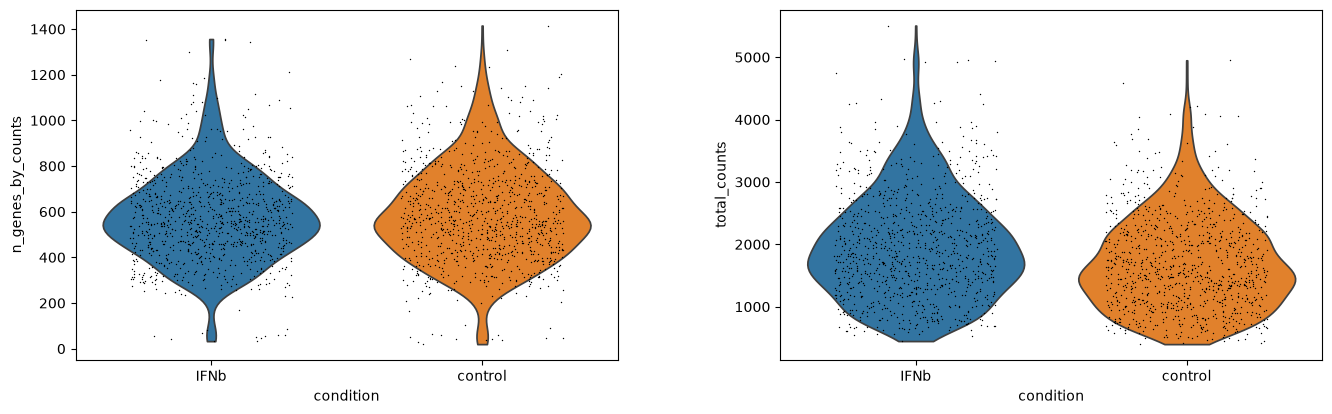

In [6]:
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    groupby="condition",
    jitter=0.3,
    multi_panel=True,
)

## Preserve raw counts, then preprocess

`store_raw_counts` snapshots `.X` into `layers["counts"]` and, with
`sidecar=True` (the default), also writes a label-indexed full-gene snapshot to
`.uns['scatrans']['raw_snapshot']` (which survives later HVG/cell subsetting)
before any HVG/normalize/log1p step — this is what lets enrichment functions
later auto-supply the correct measured-gene background via `adata=`. Count-based
DE backends (PyDESeq2, Memento) need these raw integer counts; the
`de_preprocess="auto"` step inside `differential_expression` also uses the
`.uns["log1p"]` marker scanpy sets to detect whether `.X` is already
log-normalized (see {doc}`../user_guide/standalone_de` for the
`anndata.concat()` caveat around this marker).

In [7]:
scat.store_raw_counts(adata, layer="counts")

adata_norm = adata.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)

## Backend A — single-cell Wilcoxon DE

The simplest, fastest path: scanpy's `rank_genes_groups` directly on
log-normalized single cells.

In [8]:
adata_norm, de_wilcoxon = scat.differential_expression(
    adata_norm,
    groupby="condition",
    target_group="IFNb",
    reference_group="control",
    de_method="wilcoxon",
    de_preprocess="none",  # we already normalized + log1p'd above
)
de_wilcoxon.sort_values("logFC", ascending=False).head(10)

,logFC,p_val,p_adj,baseMean
NEURL3,28.736628,3.559249e-13,8.108735e-12,0.184846
CCNA1,28.511284,9.050265e-10,1.722726e-08,0.161985
TGM1,28.196203,4.938546e-08,8.118670e-07,0.134074
SCIN,27.740952,2.353117e-05,3.016994e-04,0.101191
ZBP1,26.899183,1.143347e-02,9.292373e-02,0.058962
DNAAF1,26.736158,2.974271e-02,2.119595e-01,0.052984
PLAAT2,26.459040,9.696202e-02,5.555316e-01,0.044120
LINC02574,26.350506,8.926610e-02,5.221225e-01,0.041050
EDN1,26.106348,1.921995e-01,9.149007e-01,0.034876
FGD2,25.775055,2.358019e-01,1.000000e+00,0.027916


In [9]:
print("min p_adj:", de_wilcoxon["p_adj"].min())
print("genes with p_adj < 0.05:", (de_wilcoxon["p_adj"] < 0.05).sum())

min p_adj: 4.520186861923429e-303
genes with p_adj < 0.05: 975


:::{note}
With 8 donors per condition, this is a well-powered design — thousands of
genes reach genome-wide `p_adj < 0.05`. We still apply an explicit
`|logFC|` floor (not just significance) before calling anything a
"candidate" for enrichment, per {doc}`../statistical_guidance`: a tiny but
significant fold-change is not necessarily a biologically useful hit at
this sample size.
:::

In [10]:
candidates = scat.filter_active_genes(de_wilcoxon, pval_cutoff=0.05, logfc_cutoff=1.0)
print("candidates (p_adj<0.05, |logFC|>1):", len(candidates))
candidates.head(10)

candidates (p_adj<0.05, |logFC|>1): 338


,logFC,p_val,p_adj,baseMean
ISG15,9.089888,5.207589e-307,4.520187e-303,3.465015
ISG20,6.812402,6.431268e-301,2.791170e-297,2.526995
IFITM3,6.869534,4.420913e-300,1.279118e-296,2.336146
APOBEC3A,7.115931,4.193246e-296,9.099345e-293,2.477201
CXCL10,11.263014,1.463436e-291,2.540524e-288,2.619467
TNFSF10,9.104015,5.874617e-291,8.498612e-288,1.877073
RSAD2,8.830932,3.687798e-286,4.572870e-283,1.855343
IFIT1,9.197159,3.932408e-284,4.266663e-281,1.794139
IDO1,7.522523,5.976569e-264,5.764069e-261,1.843162
IFI6,5.062495,1.368677e-259,1.188012e-256,1.818738


## Backend B — pseudobulk + PyDESeq2

With 8 biological replicates (donors) per group, aggregating to pseudobulk and
running count-based DESeq2 is the more defensible choice for a real
publication (see the DE-backend decision guide in
{doc}`../user_guide/workflow`). We compare its top genes against the
Wilcoxon single-cell result above.

In [11]:
adata_pb = adata.copy()
adata_pb, de_pseudobulk = scat.differential_expression(
    adata_pb,
    groupby="condition",
    target_group="IFNb",
    reference_group="control",
    use_pseudobulk=True,
    sample_col="sample",
    pseudobulk_de_backend="pydeseq2",
)
print("min p_adj (pseudobulk):", de_pseudobulk["p_adj"].min())
print("n p_adj<0.05:", (de_pseudobulk["p_adj"] < 0.05).sum())
de_pseudobulk.sort_values("logFC", ascending=False).head(10)

min p_adj (pseudobulk): 6.2918048499396105e-164
n p_adj<0.05: 1872


,logFC,p_val,p_adj,baseMean
CCL8,9.440311,4.585743e-47,6.119419e-45,2620.8750
CXCL10,9.327170,3.598688e-60,9.395704e-58,3965.9375
CXCL11,9.013045,1.519201e-47,2.073365e-45,512.0625
HESX1,8.028856,3.605421e-14,8.295231e-13,26.5000
TNFSF10,7.777737,4.037931e-40,4.253996e-38,610.3750
HES4,7.731653,2.235594e-34,1.716765e-32,66.5000
IFIT1,7.673582,2.111417e-30,1.320735e-28,565.6250
CCNA1,7.649019,2.753425e-10,4.444709e-09,15.8125
NEURL3,7.599409,2.901825e-10,4.659213e-09,15.1250
NEXN,7.427516,4.063732e-12,7.948766e-11,17.3750


In [12]:
top_wilcoxon = set(de_wilcoxon.sort_values("logFC", ascending=False).head(20).index)
top_pseudobulk = set(de_pseudobulk.sort_values("logFC", ascending=False).head(20).index)
print(
    f"overlap of top-20 genes (Wilcoxon vs. pseudobulk PyDESeq2): {len(top_wilcoxon & top_pseudobulk)} / 20"
)

overlap of top-20 genes (Wilcoxon vs. pseudobulk PyDESeq2): 4 / 20


## Backend C — Memento (method-of-moments)

[Memento](https://doi.org/10.1016/j.cell.2024.09.044) (*Cell*, 2024) is a
method-of-moments estimator that works directly on raw single-cell counts
(no pseudobulk aggregation, no log-normalization). It needs `use_memento_de=True`
and raw integer counts, which is exactly why we called `store_raw_counts`
above.

In [13]:
adata_mem = adata.copy()
adata_mem, de_memento = scat.differential_expression(
    adata_mem,
    groupby="condition",
    target_group="IFNb",
    reference_group="control",
    use_memento_de=True,
)
de_memento.sort_values("logFC", ascending=False).head(10)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    1.2s


[Parallel(n_jobs=-1)]: Done 368 tasks      | elapsed:    3.7s


[Parallel(n_jobs=-1)]: Done 1368 tasks      | elapsed:   11.1s


[Parallel(n_jobs=-1)]: Done 1529 out of 1552 | elapsed:   12.3s remaining:    0.2s


[Parallel(n_jobs=-1)]: Done 1552 out of 1552 | elapsed:   12.5s finished


,logFC,p_val,p_adj,memento_de_se,memento_dv_coef,memento_dv_se,memento_dv_pval,baseMean
CCL8,9.588807,9.948581e-36,9.897562e-35,0.514576,-3.249011,0.940929,2.784808e-04,21.840625
CXCL10,9.116839,8.129276e-53,1.356628e-51,0.401810,-3.989855,0.405902,4.202351e-23,33.049479
RSAD2,7.226353,1.186443e-99,4.491120e-98,0.234314,-2.514830,0.267345,2.574770e-21,5.065625
ISG15,7.101595,0.000000e+00,0.000000e+00,0.115672,-4.308555,0.141805,4.519980e-203,57.918229
APOBEC3B,6.681565,2.424253e-43,3.083967e-42,0.329426,-1.542767,0.327226,1.230174e-06,6.601563
IL1RN,6.121014,6.047870e-74,1.422166e-72,0.230836,-1.944547,0.226177,4.146491e-18,2.501042
IDO1,6.043188,3.042861e-126,1.628455e-124,0.173963,-2.475296,0.255032,1.431539e-22,4.902604
APOBEC3A,5.692846,0.000000e+00,0.000000e+00,0.093716,-2.334758,0.156924,2.344423e-50,10.776563
IFITM3,5.308488,2.150983e-294,4.769038e-292,0.100170,-3.584216,0.223486,3.490512e-58,7.180208
ISG20,5.250385,0.000000e+00,0.000000e+00,0.095398,-3.393983,0.227123,8.613318e-51,9.423438


All three backends agree on the strongest hits (classic interferon-
stimulated genes) — a contrast worth noting with the underpowered 3-vs-3 EC
design used in {doc}`t_ec_active_transcription`, where backend choice
visibly changes which genes come out on top. Proper multi-donor replication
is what buys that agreement; always report which backend was used regardless,
per {doc}`../statistical_guidance`.

## Functional enrichment — the full tour

We use the real significant candidate list from Backend A
(`p_adj<0.05`, `|logFC|>1`) for the ORA methods below (`run_enrichment`,
`run_kegg`, `run_go`), and the full ranked `logFC` list for `run_gsea`.

In [14]:
candidate_genes = candidates.index.tolist()
down_genes = de_wilcoxon[de_wilcoxon["logFC"] < 0].sort_values("p_val").head(100).index.tolist()
len(candidate_genes), len(down_genes)

(338, 100)

### Over-representation analysis (ORA): GO Biological Process

In [15]:
go_res = scat.run_enrichment(
    candidate_genes,
    gene_sets="GO_Biological_Process",
    organism="human",
    adata=adata_norm,  # auto-supplies the stored measured-gene background
    return_all=True,
)
print(
    f"{len(go_res)} GO BP terms tested, {(go_res['p.adjust'] < 0.05).sum()} significant at p.adjust<0.05"
)
go_res.sort_values("pvalue").head(10)[["Term", "Count", "GeneRatio", "pvalue", "p.adjust"]]

5949 GO BP terms tested, 311 significant at p.adjust<0.05


,Term,Count,GeneRatio,pvalue,p.adjust
1,response to cytokine (GO:0034097),84,0.264151,1.763400e-31,7.564910e-28
2,defense response to virus (GO:0051607),56,0.176101,2.781547e-31,7.564910e-28
0,response to peptide (GO:1901652),84,0.264151,3.814881e-31,7.564910e-28
3,response to virus (GO:0009615),62,0.194969,2.353383e-30,3.500068e-27
4,cellular response to cytokine stimulus (GO:007...,67,0.210692,1.817758e-22,2.162768e-19
5,response to type II interferon (GO:0034341),30,0.094340,1.037422e-21,1.028604e-18
6,negative regulation of viral genome replicatio...,20,0.062893,1.928451e-18,1.638908e-15
7,regulation of response to biotic stimulus (GO:...,57,0.179245,3.071294e-18,2.283891e-15
8,viral process (GO:0016032),45,0.141509,2.569108e-17,1.698180e-14
9,cytokine-mediated signaling pathway (GO:0019221),48,0.150943,3.043458e-17,1.810553e-14


Top hits are exactly what you'd want from a real IFN-β stimulation
experiment: "response to cytokine", "defense response to virus", "response
to type II interferon" — genuine, well-powered antiviral-response signal,
not an artifact of the gene list.

### KEGG pathways

In [16]:
kegg_res = scat.run_kegg(
    candidate_genes,
    organism="human",
    adata=adata_norm,
    return_all=True,
)
kegg_res.sort_values("pvalue").head(10)[["Term", "Count", "pvalue", "p.adjust"]]

,Term,Count,pvalue,p.adjust
0,Cytokine-cytokine receptor interaction(hsa04060),16,0.000023,0.004731
1,Chemokine signaling pathway(hsa04062),16,0.000126,0.013082
2,Antigen processing and presentation(hsa04612),9,0.000513,0.035407
3,Cytosolic DNA-sensing pathway(hsa04623),7,0.000789,0.040818
4,Nicotinate and nicotinamide metabolism(hsa00760),4,0.002663,0.110240
5,Toll-like receptor signaling pathway(hsa04620),9,0.005838,0.201408
6,Hepatitis C(hsa05160),9,0.013813,0.367807
8,Rheumatoid arthritis(hsa05323),7,0.015407,0.367807
7,Cell adhesion molecule (CAM) interaction(hsa04...,7,0.016916,0.367807
9,RIG-I-like receptor signaling pathway(hsa04622),6,0.017768,0.367807


"Cytokine-cytokine receptor interaction" and "Chemokine signaling
pathway" top the KEGG list — consistent with the GO result above and with
the antiviral/inflammatory biology IFN-β is expected to induce.

### GO, all three ontologies at once (`ontology="ALL"`)

In [17]:
go_all = scat.run_go(
    candidate_genes,
    ontology="ALL",
    organism="human",
    adata=adata_norm,
    return_all=True,
    adjust_across_all=True,  # single BH correction across BP+CC+MF combined
)
print("ontologies covered:", list(go_all.attrs["per_ontology_attrs"].keys()))
go_all.sort_values("pvalue").head(6)[["Term", "Count", "pvalue", "p.adjust"]]

ontologies covered: ['BP', 'CC', 'MF']


,Term,Count,pvalue,p.adjust
1,response to cytokine (GO:0034097),84,1.763400e-31,7.564910e-28
2,defense response to virus (GO:0051607),56,2.781547e-31,7.564910e-28
0,response to peptide (GO:1901652),84,3.814881e-31,7.564910e-28
3,response to virus (GO:0009615),62,2.353383e-30,3.500068e-27
4,cellular response to cytokine stimulus (GO:007...,67,1.817758e-22,2.162768e-19
5,response to type II interferon (GO:0034341),30,1.037422e-21,1.028604e-18


### Pre-ranked GSEA

`run_gsea` takes a full ranked gene list (here, `logFC` from the Wilcoxon
DE result) rather than a fixed candidate cutoff — every gene contributes,
weighted by its rank.

:::{note}
`nperm` controls the permutation-based null distribution; we use a modest
`nperm=100` here to keep this tutorial cell fast. For a manuscript, prefer a
larger `nperm` (>=1000).
:::

In [18]:
ranked = de_wilcoxon["logFC"].sort_values(ascending=False)
gsea_res = scat.run_gsea(
    ranked_genes=ranked,
    gene_sets="GO_Biological_Process",
    organism="human",
    nperm=100,
    min_size=15,
)
gsea_res.sort_values("p.adjust")[["Term", "NES", "pvalue", "p.adjust", "leading_edge"]].head(10)

2026-08-07 22:08:21,923 [WARNING] Duplicated values found in preranked stats: 0.90% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,NES,pvalue,p.adjust,leading_edge
5,regulation of regulatory T cell differentiatio...,1.993952,0.01,0.010000,LAG3;KAT2A;MDK;SOCS1;IL4I1;PSMB9;PSMA4;FANCA;I...
4,regulation of viral life cycle (GO:1903900),2.018951,0.01,0.010000,CH25H;APOBEC3H;IFIT1;ISG15;RSAD2;APOBEC3A;IFIT...
2,regulatory T cell differentiation (GO:0045066),2.021892,0.01,0.010000,LAG3;KAT2A;MDK;SOCS1;IL4I1;PSMB9;PSMA4;FANCA;I...
3,negative regulation of viral process (GO:0048525),2.019023,0.01,0.010000,CH25H;APOBEC3H;TRIM14;IFIT1;ISG15;RSAD2;APOBEC...
6,T-helper 1 cell differentiation (GO:0045063),1.975791,0.01,0.011627,IL18RAP;IL18R1;IL27;CD80;PSMB9;PSMA4;ASCL2
1,negative regulation of viral genome replicatio...,2.035130,0.01,0.013565,APOBEC3H;IFIT1;ISG15;RSAD2;APOBEC3A;IFITM3;ISG...
8,interferon-mediated signaling pathway (GO:0140...,1.934989,0.01,0.018086,ZBP1;USP18;TXK;ISG15;IFITM3;IFITM1;OAS2;OAS3;I...
7,response to type I interferon (GO:0034340),1.944836,0.01,0.020347,ZBP1;USP18;CH25H;IFIT1;ISG15;IFITM3;MX1;IFITM1...
9,regulation of immune effector process (GO:0002...,1.914152,0.01,0.021704,LAG3;TNFSF18;IL6;STAP1;IL18R1;SLAMF6;XCL1;RSAD...
10,type I interferon-mediated signaling pathway (...,1.905964,0.01,0.022197,ZBP1;USP18;ISG15;IFITM3;IFITM1;OAS2;OAS3;IFITM...


:::{note}
`scat.pl.gseaplot(...)` and `scat.pl.enrich_dotplot(gsea_res, x="NES", ...)` are
shown below. Large GSEA tables used to be slow to plot because full running-score
curves were stored in DataFrame `.attrs` and deep-copied on ordinary pandas ops;
that is fixed in current scATrans (see {doc}`../changelog`).
:::

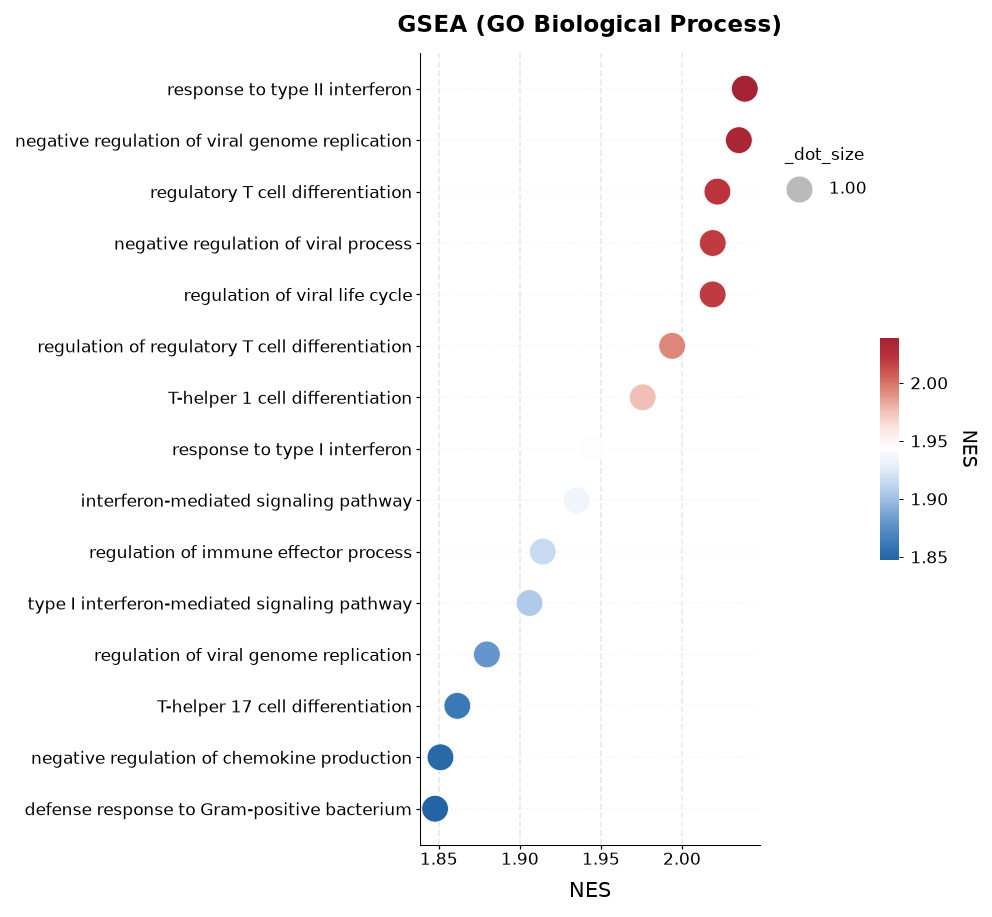

In [19]:
scat.pl.enrich_dotplot(
    gsea_res, top_n=15, x="NES", color_by="NES", title="GSEA (GO Biological Process)"
);

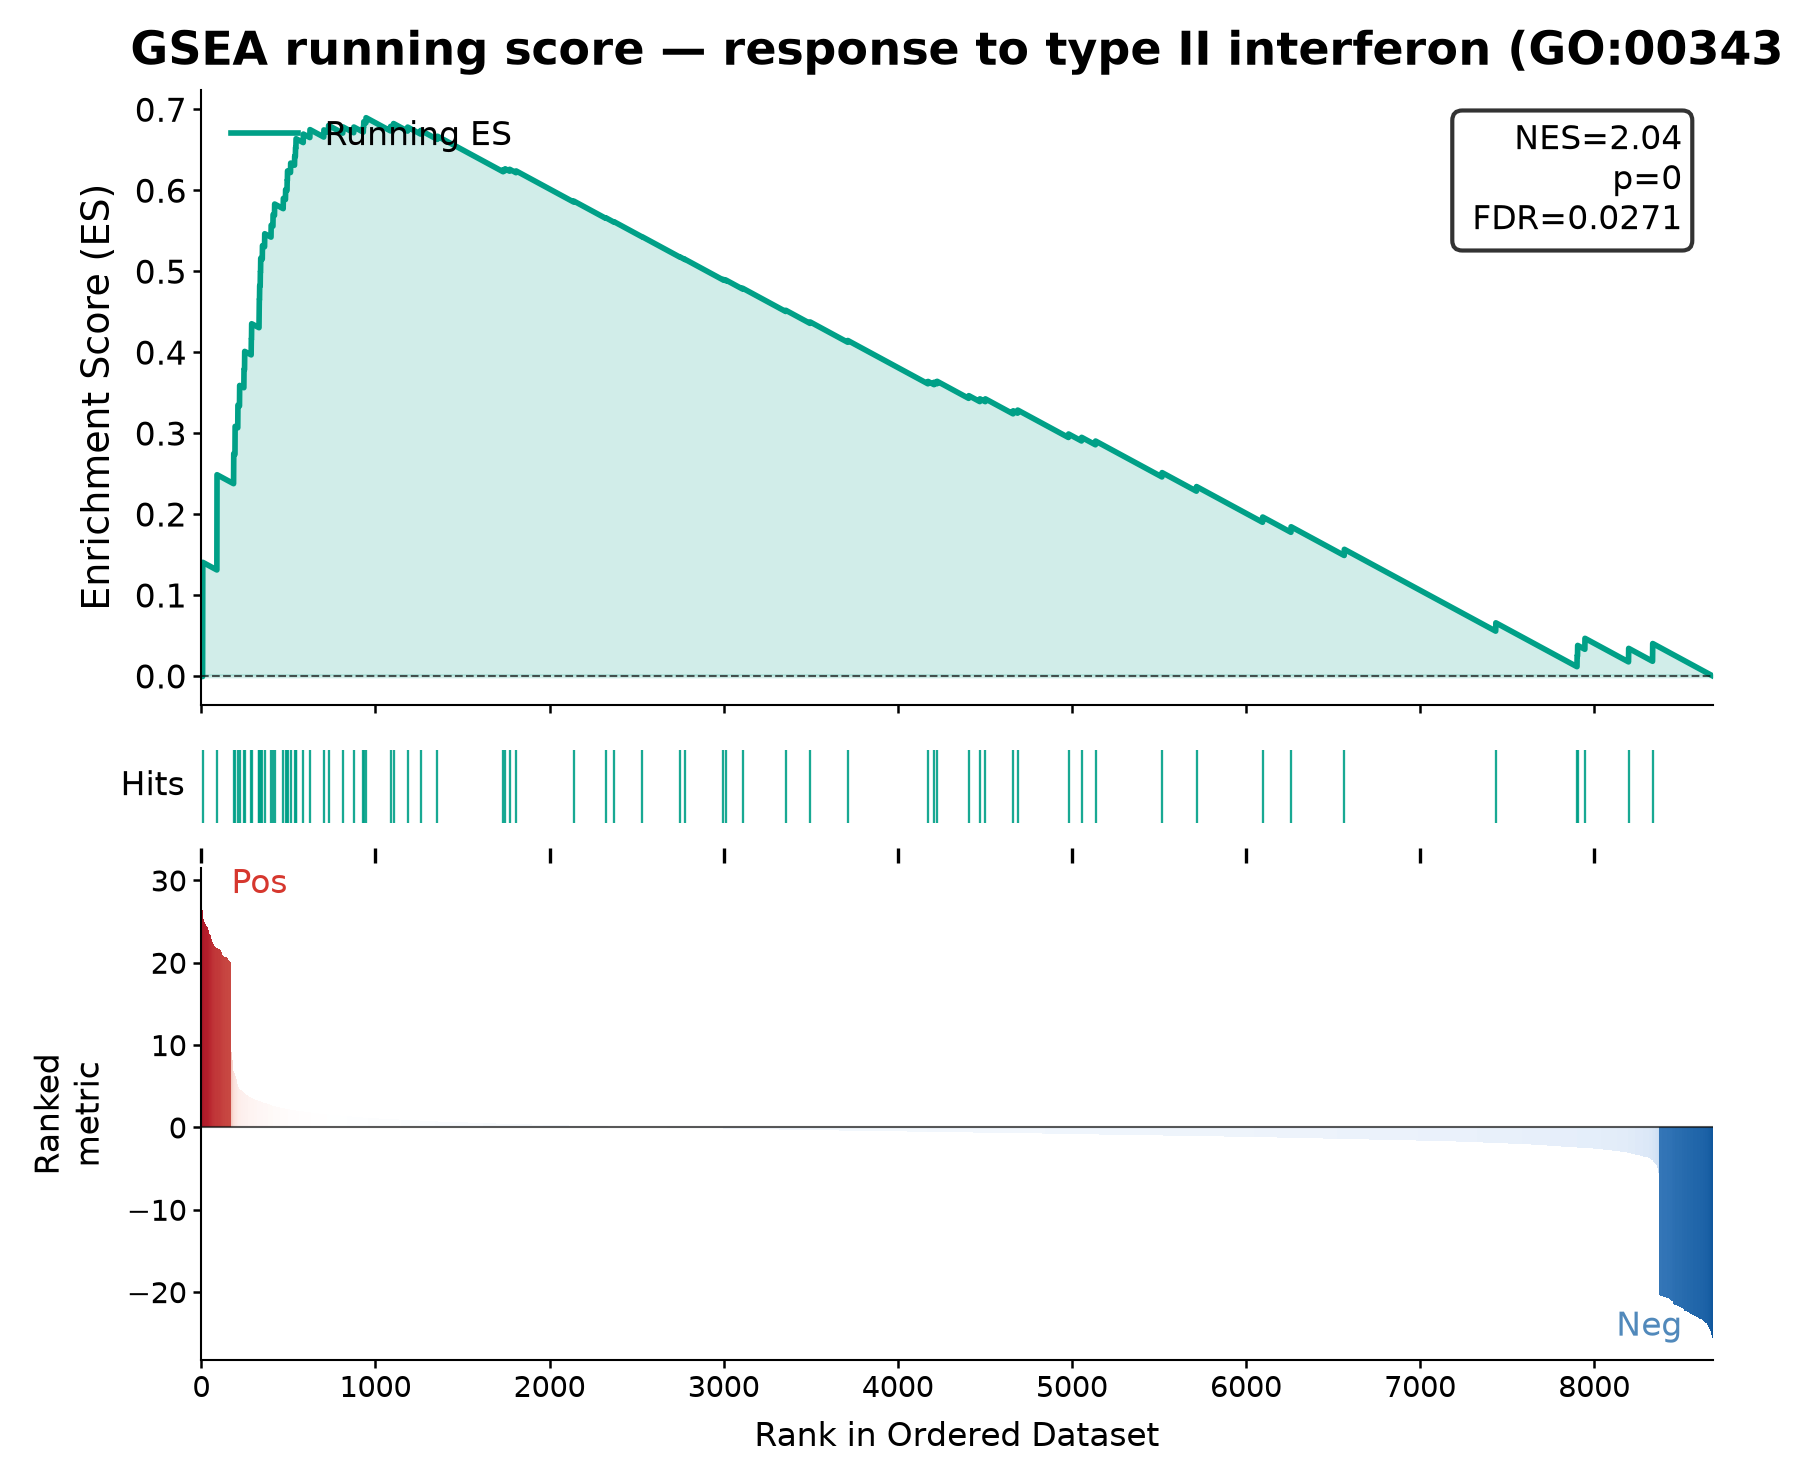

In [20]:
top_term = gsea_res.iloc[0]["Term"]
scat.pl.gseaplot(ranked, gsea_res, term=top_term, title=f"GSEA running score — {top_term[:40]}");

### Redundancy reduction: `simplify_enrichment`

GO is deliberately redundant — "response to virus", "defense response to
virus", and "response to type II interferon" all share most of their genes.
`simplify_enrichment` collapses near-duplicate terms to one representative
per cluster, so a results table (or a plot) is actually readable.

We simplify the **significant** terms only (`go_res` above, not the full
tested universe) — that is the realistic use case: you have too many
significant hits to report, not too many tested-but-null ones.

In [21]:
go_sig = go_res[go_res["p.adjust"] < 0.05].copy()
print("significant GO BP terms before simplify:", len(go_sig))

simplified_jaccard = scat.simplify_enrichment(
    go_sig,
    method="jaccard",
    similarity_cutoff=0.5,
    min_count=3,
)
print(f"jaccard: {len(go_sig)} -> {len(simplified_jaccard)} terms")

simplified_denester = scat.simplify_enrichment(
    go_sig,
    method="pathway_denester",
    min_count=3,
)
print(f"pathway_denester: {len(go_sig)} -> {len(simplified_denester)} terms")

significant GO BP terms before simplify: 311
jaccard: 311 -> 99 terms


pathway_denester: 311 -> 105 terms


What actually happens to a specific redundant pair — `jaccard` keeps
one representative per similarity cluster and drops the rest, even when the
dropped term was individually more significant:

In [22]:
kept = set(simplified_jaccard["Term"])
dropped = go_sig[~go_sig["Term"].isin(kept)].sort_values("p.adjust")
print("most significant term that got folded away:")
print(dropped[["Term", "Count", "p.adjust"]].head(3))
print("\nkept as its representative:")
print(simplified_jaccard.sort_values("p.adjust")[["Term", "Count", "p.adjust"]].head(3))

most significant term that got folded away:
                                                Term  Count      p.adjust
1                  response to cytokine (GO:0034097)     84  7.564910e-28
3                     response to virus (GO:0009615)     62  3.500068e-27
4  cellular response to cytokine stimulus (GO:007...     67  2.162768e-19

kept as its representative:
                                          Term  Count      p.adjust
0             response to peptide (GO:1901652)     84  7.564910e-28
1       defense response to virus (GO:0051607)     56  7.564910e-28
2  response to type II interferon (GO:0034341)     30  1.028604e-18


And the same effect, visually — the raw significant-term dotplot is
dominated by many near-duplicate viral-response rows; the simplified one
keeps one representative per cluster and is actually legible at a glance.

`color_by="neg_log10_padj"` here instead of the default `"p.adjust"`: with
this many strongly significant terms, raw `p.adjust` values cluster right
next to 0, so the default linear color scale paints nearly every dot the
same pale end of the colormap — `-log10(p.adj)` spreads them back out.

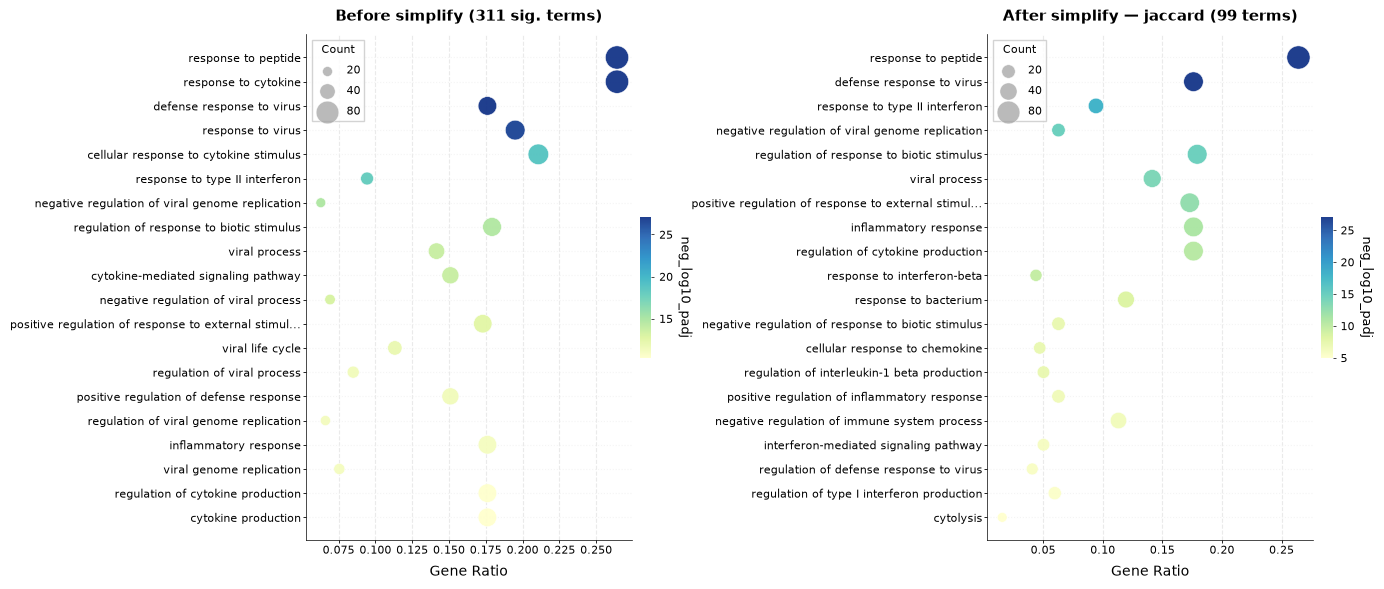

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scat.pl.enrich_dotplot(
    go_sig,
    top_n=20,
    title=f"Before simplify ({len(go_sig)} sig. terms)",
    ax=axes[0],
    color_by="neg_log10_padj",
)
scat.pl.enrich_dotplot(
    simplified_jaccard,
    top_n=20,
    title=f"After simplify — jaccard ({len(simplified_jaccard)} terms)",
    ax=axes[1],
    color_by="neg_log10_padj",
)
plt.tight_layout()

### Comparing gene sets across cell types: `compare_enrichment`

`compare_enrichment` runs ORA across several named gene lists at once
(clusterProfiler's `compareCluster` style) and returns a single table with a
`Cluster` column — exactly the shape `enrich_upsetplot` / `enrich_vennplot`
expect. The natural use of this is comparing **clusters/cell types**, not
just up- vs. down-regulated genes within one — so here we bring in CD4 T
cells (the dataset's weaker IFN-β responder) as a second, real cluster.

In [24]:
cd4 = adata_full[adata_full.obs["celltype"] == "CD4 T cells"].copy()
scat.store_raw_counts(cd4, layer="counts")
cd4_norm = cd4.copy()
sc.pp.normalize_total(cd4_norm, target_sum=1e4)
sc.pp.log1p(cd4_norm)

cd4_norm, de_cd4 = scat.differential_expression(
    cd4_norm,
    groupby="condition",
    target_group="IFNb",
    reference_group="control",
    de_method="wilcoxon",
    de_preprocess="none",
)
candidates_cd4 = scat.filter_active_genes(de_cd4, pval_cutoff=0.05, logfc_cutoff=1.0)
candidate_genes_cd4 = candidates_cd4.index.tolist()
print(
    "Monocyte candidates:", len(candidate_genes), " |  CD4 T candidates:", len(candidate_genes_cd4)
)

Monocyte candidates: 338  |  CD4 T candidates: 99


Monocytes mount a much larger transcriptional IFN-β response than CD4
T cells in this dataset — consistent with the original Kang et al. finding
that innate/myeloid cells respond more strongly than most lymphocytes.

In [25]:
cmp_res = scat.compare_enrichment(
    {"Monocyte": candidate_genes, "CD4T": candidate_genes_cd4},
    organism="human",
    gene_sets="GO_Biological_Process",
    adata=adata_norm,
)
cmp_res["Cluster"].value_counts()

Cluster
Monocyte    311
CD4T        129
Name: count, dtype: int64

`concat_compare_results` does the same reshaping when you already have
separate result tables in hand (e.g. combining our GO and KEGG results
above into one comparable table, for the Monocyte cluster):

In [26]:
concat_res = scat.concat_compare_results({"GO": go_res, "KEGG": kegg_res})
concat_res["Cluster"].value_counts()

Cluster
GO      5949
KEGG     207
Name: count, dtype: int64

### Exporting results

`save_enrichment_report` writes CSV/TSV/Excel + a metadata JSON (gene-set
provenance, universe info, package version); `expand_enrichment_genes`
pivots to one row per gene for network/follow-up analyses. We write to a
scratch temp directory here rather than into the docs tree.

In [27]:
import os
import tempfile

tmpdir = tempfile.mkdtemp()
saved_paths = scat.save_enrichment_report(
    kegg_res,
    prefix=os.path.join(tmpdir, "kegg_demo"),
    save_excel=True,
    save_csv=True,
    save_tsv=True,
    save_metadata=True,
    save_term_gene_table=True,
)
saved_paths

{'results_csv': '/tmp/tmpaq305cew/kegg_demo_results.csv',
 'term_gene_table_csv': '/tmp/tmpaq305cew/kegg_demo_term_gene_table.csv',
 'results_tsv': '/tmp/tmpaq305cew/kegg_demo_results.tsv',
 'term_gene_table_tsv': '/tmp/tmpaq305cew/kegg_demo_term_gene_table.tsv',
 'metadata_json': '/tmp/tmpaq305cew/kegg_demo_metadata.json',
 'results_xlsx': '/tmp/tmpaq305cew/kegg_demo_results.xlsx'}

In [28]:
long_table = scat.expand_enrichment_genes(kegg_res)
print(long_table.shape)
long_table.head()

(351, 14)


,Term,Description,Gene,Count,GeneRatio,GeneRatio_str,BgRatio,BgRatio_str,FoldEnrichment,RichFactor,Overlap,pvalue,p.adjust,TermSize
0,Cytokine-cytokine receptor interaction(hsa04060),,CCL2,16,0.115108,16/139,0.035839,103/2874,3.211846,0.15534,16/103,0.000023,0.004731,103
1,Cytokine-cytokine receptor interaction(hsa04060),,CCL3,16,0.115108,16/139,0.035839,103/2874,3.211846,0.15534,16/103,0.000023,0.004731,103
2,Cytokine-cytokine receptor interaction(hsa04060),,CCL3L3,16,0.115108,16/139,0.035839,103/2874,3.211846,0.15534,16/103,0.000023,0.004731,103
3,Cytokine-cytokine receptor interaction(hsa04060),,CCL4,16,0.115108,16/139,0.035839,103/2874,3.211846,0.15534,16/103,0.000023,0.004731,103
4,Cytokine-cytokine receptor interaction(hsa04060),,CCL4L2,16,0.115108,16/139,0.035839,103/2874,3.211846,0.15534,16/103,0.000023,0.004731,103


## Plotting gallery

Every `scat.pl.*` function below accepts `ax=`, `save_path=`, `show=`,
`figsize=`, and `use_style=` for embedding in multi-panel publication
figures (see {doc}`../user_guide/plotting`).

### Volcano plots (3 styles)

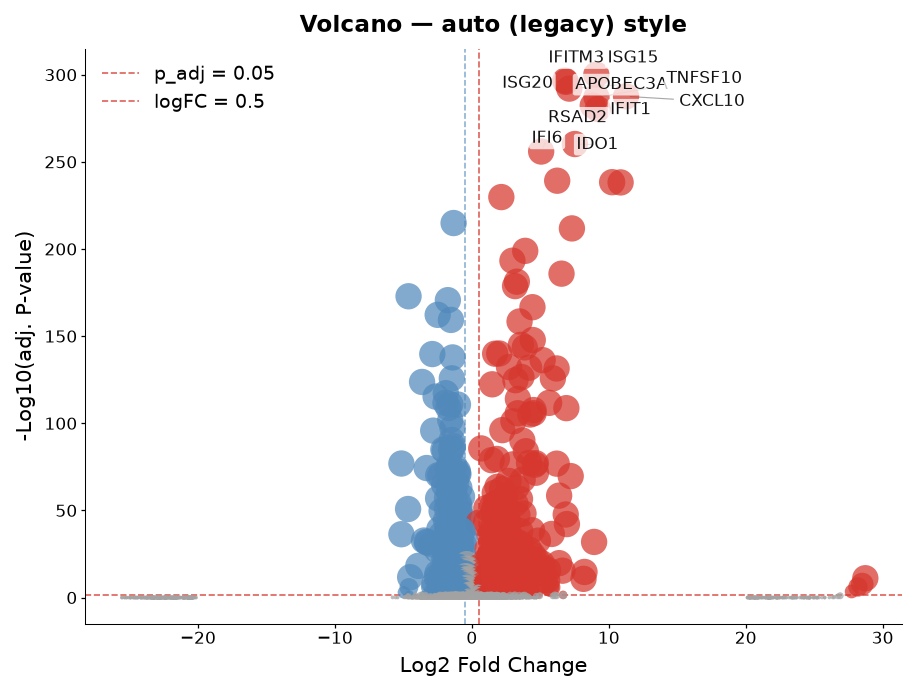

In [29]:
scat.pl.volcano_plot(de_wilcoxon, style="auto", top_n=10, title="Volcano — auto (legacy) style");

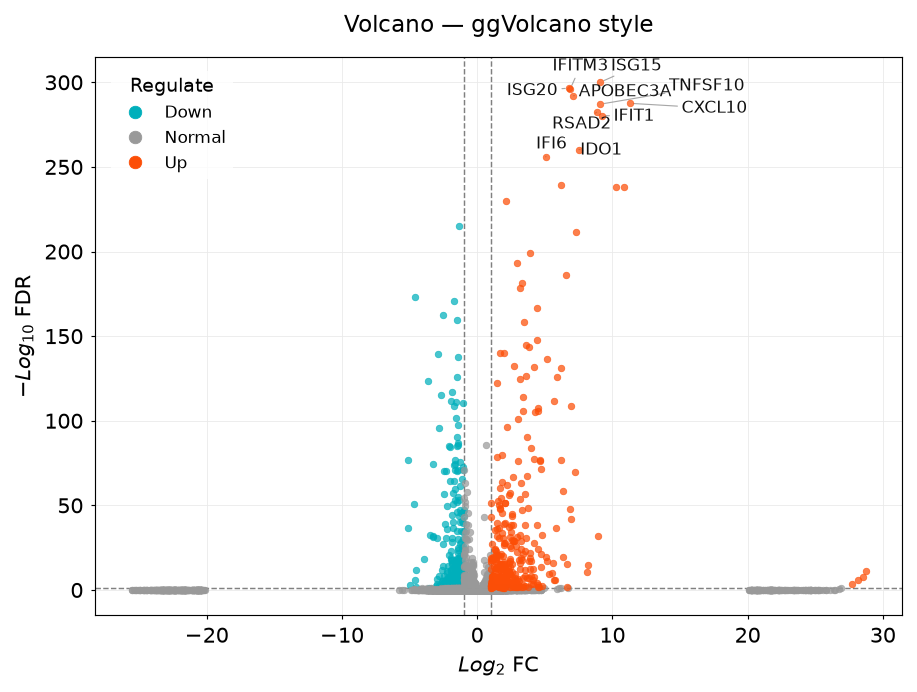

In [30]:
scat.pl.volcano_plot(
    de_wilcoxon,
    style="ggvolcano",
    top_n=10,
    logfc_cutoff=1.0,
    pval_cutoff=0.05,
    title="Volcano — ggVolcano style",
);

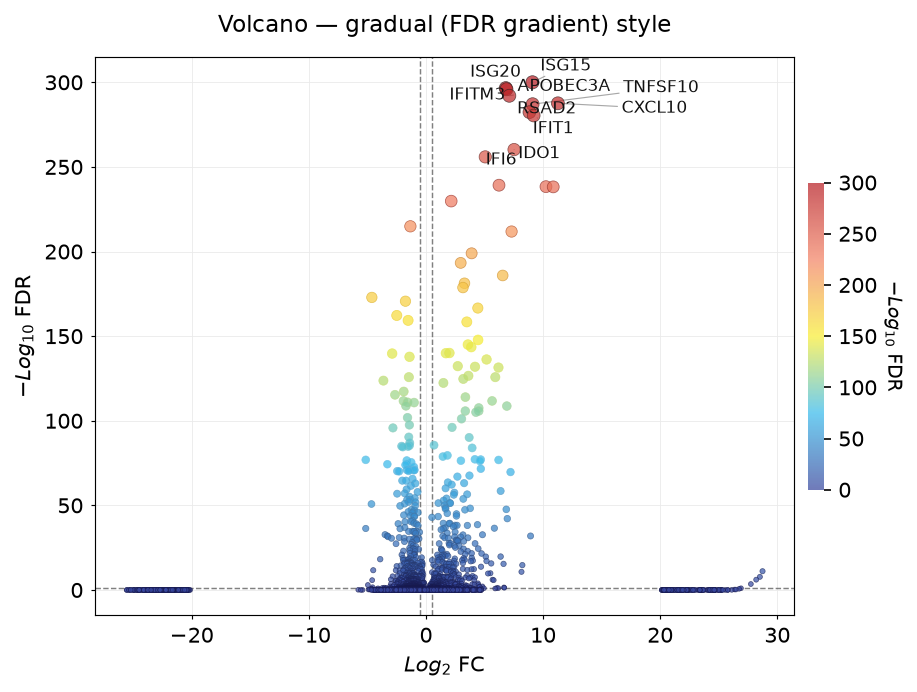

In [31]:
scat.pl.volcano_plot(
    de_wilcoxon, style="gradual", top_n=10, title="Volcano — gradual (FDR gradient) style"
);

### Enrichment dot plots and bar plot

`color_by="neg_log10_padj"` again, for the same contrast reason as the
simplify comparison above — the default `"p.adjust"` coloring washes out
once most terms are strongly significant.

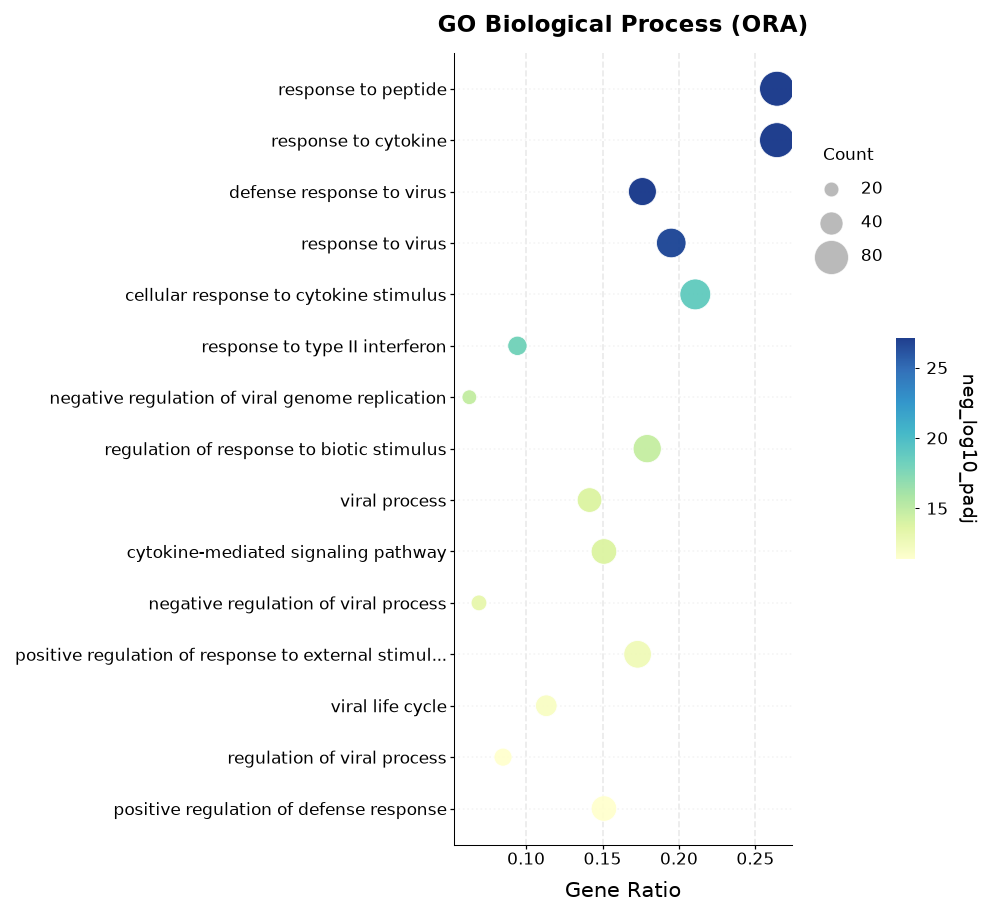

In [32]:
scat.pl.enrich_dotplot(
    go_res, top_n=15, title="GO Biological Process (ORA)", color_by="neg_log10_padj"
);

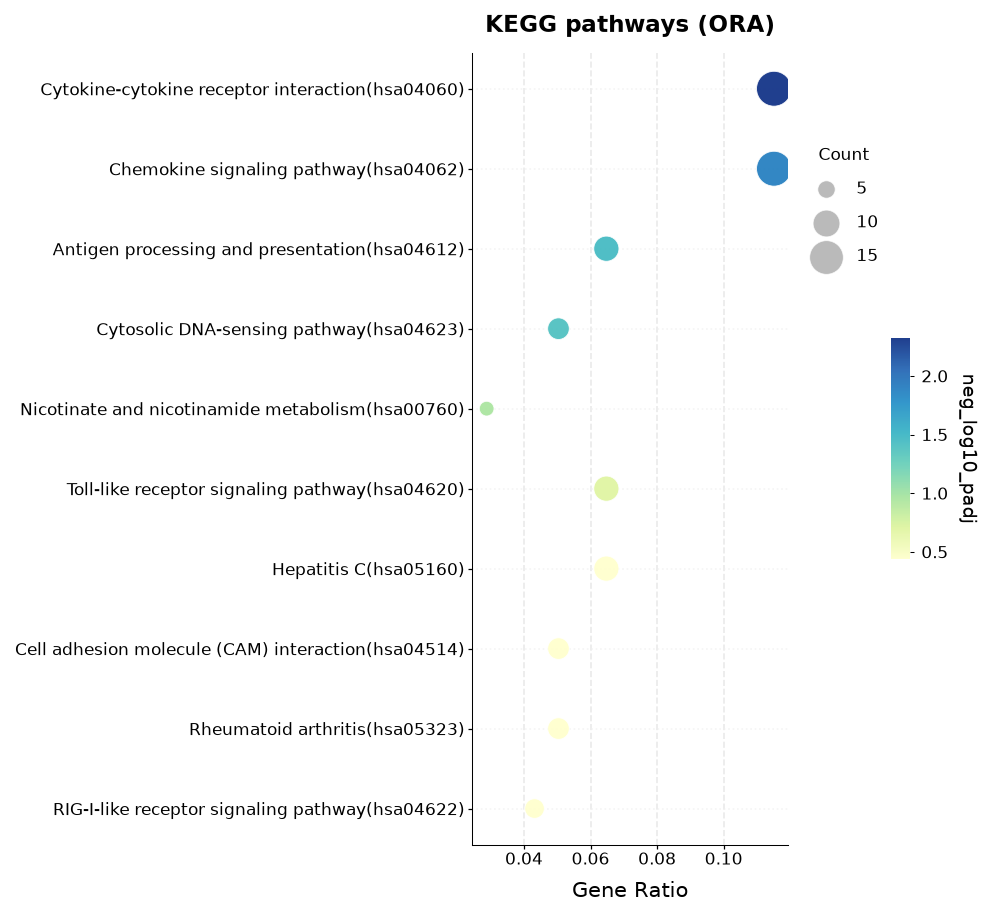

In [33]:
scat.pl.enrich_dotplot(kegg_res, top_n=10, title="KEGG pathways (ORA)", color_by="neg_log10_padj");

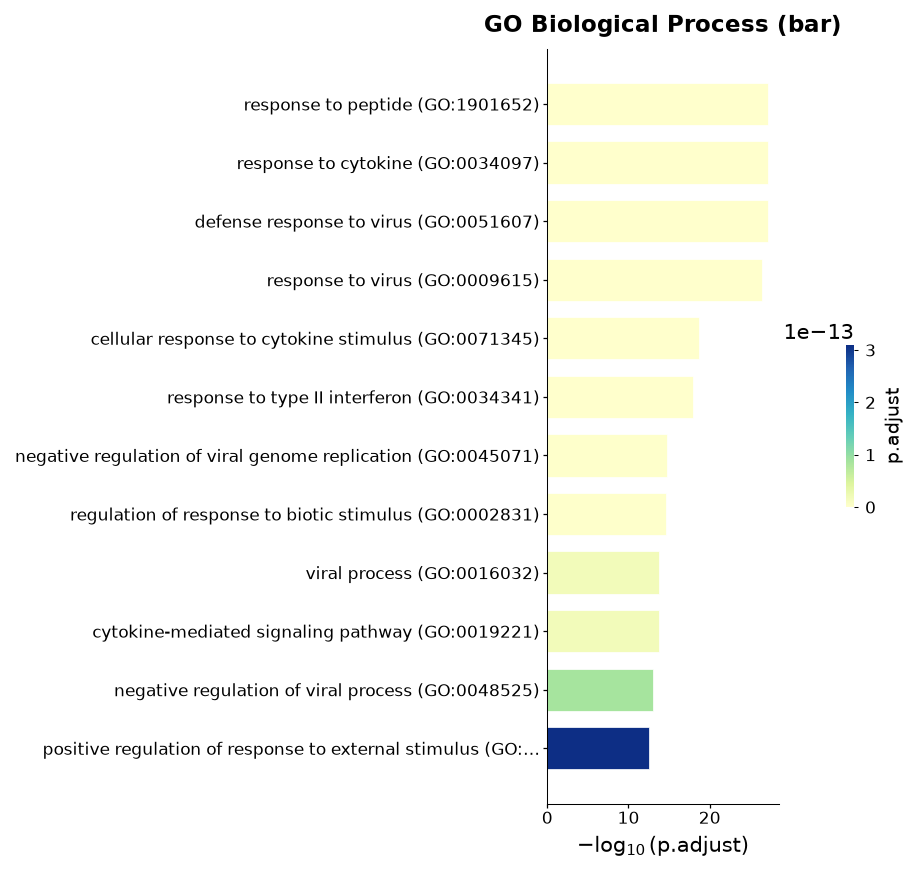

In [34]:
scat.pl.enrich_barplot(go_res, top_n=12, title="GO Biological Process (bar)");

### Multi-group comparison dot plot (compareCluster grid)

`compare_dotplot` draws the classic clusterProfiler `compareCluster` view: the
**groups are columns** on the x-axis, **enriched terms are rows** on the y-axis,
and a dot sits at each (group, term) cell where that term is enriched — dot size
= `GeneRatio`, color = `p.adjust` (red = most significant). Terms shared across
groups line up on one row with a dot in each column.

Two different axes of comparison, both valid uses of the same plot:
Monocyte vs. CD4T (cell-type axis) and GO vs. KEGG (database axis).

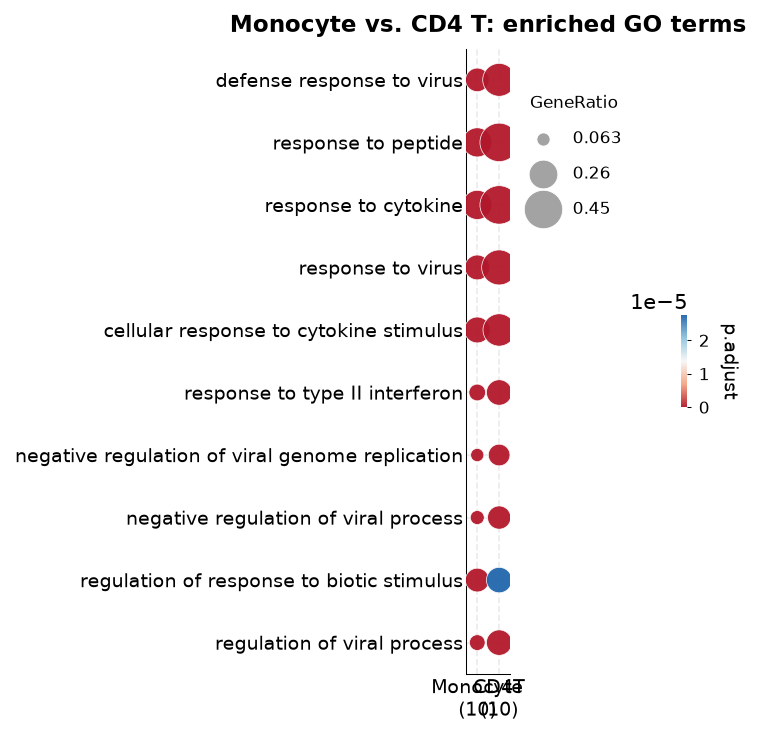

In [35]:
scat.pl.compare_dotplot(
    cmp_res,  # Monocyte vs. CD4T (Cluster column = cell type)
    top_n=8,
    title="Monocyte vs. CD4 T: enriched GO terms",
);

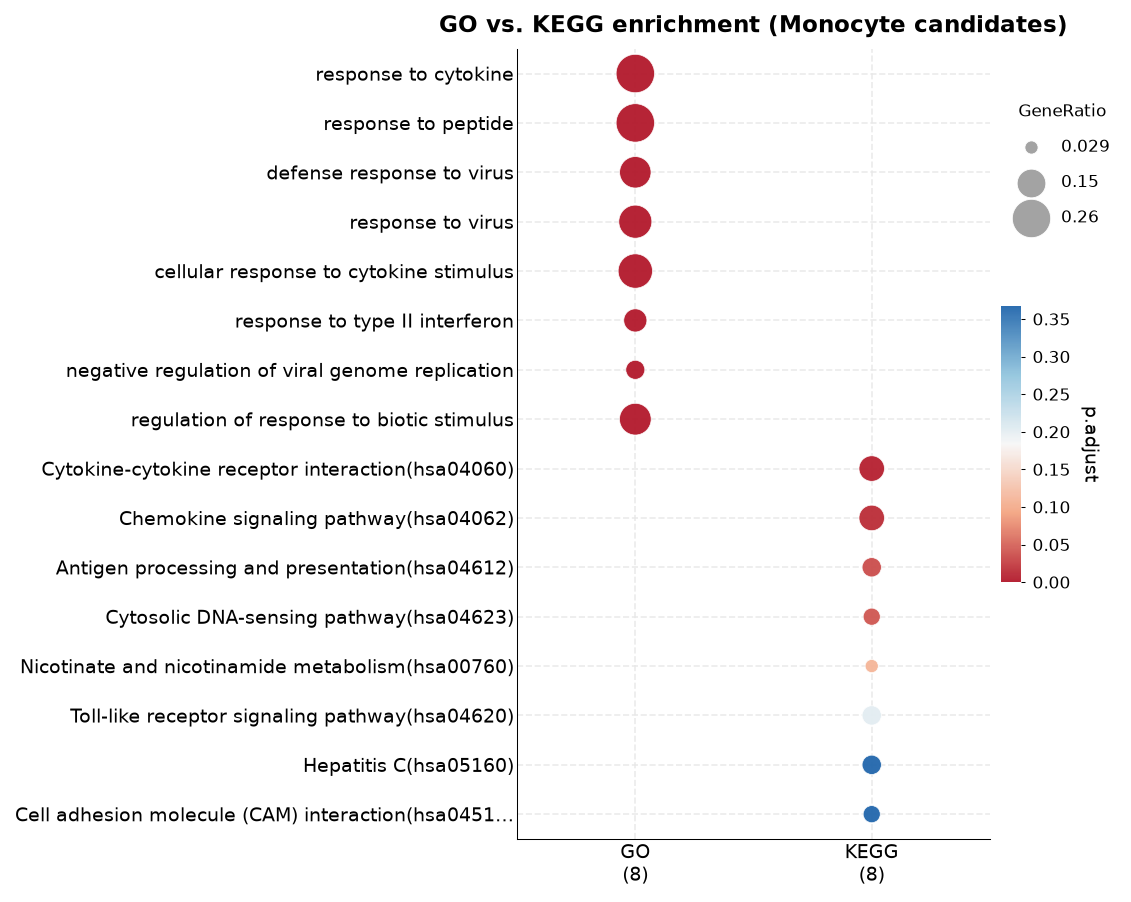

In [36]:
scat.pl.compare_dotplot(
    concat_res,  # GO + KEGG combined (Cluster column = GO / KEGG)
    top_n=8,
    title="GO vs. KEGG enrichment (Monocyte candidates)",
);

### UpSet and Venn: comparing enrichment across clusters

Built for `compare_enrichment`/`concat_compare_results` output (a `Cluster`
column identifies each group). Shared terms sit in the intersection; terms
private to one cell type show the biology that actually differs between
them, not just a magnitude difference.

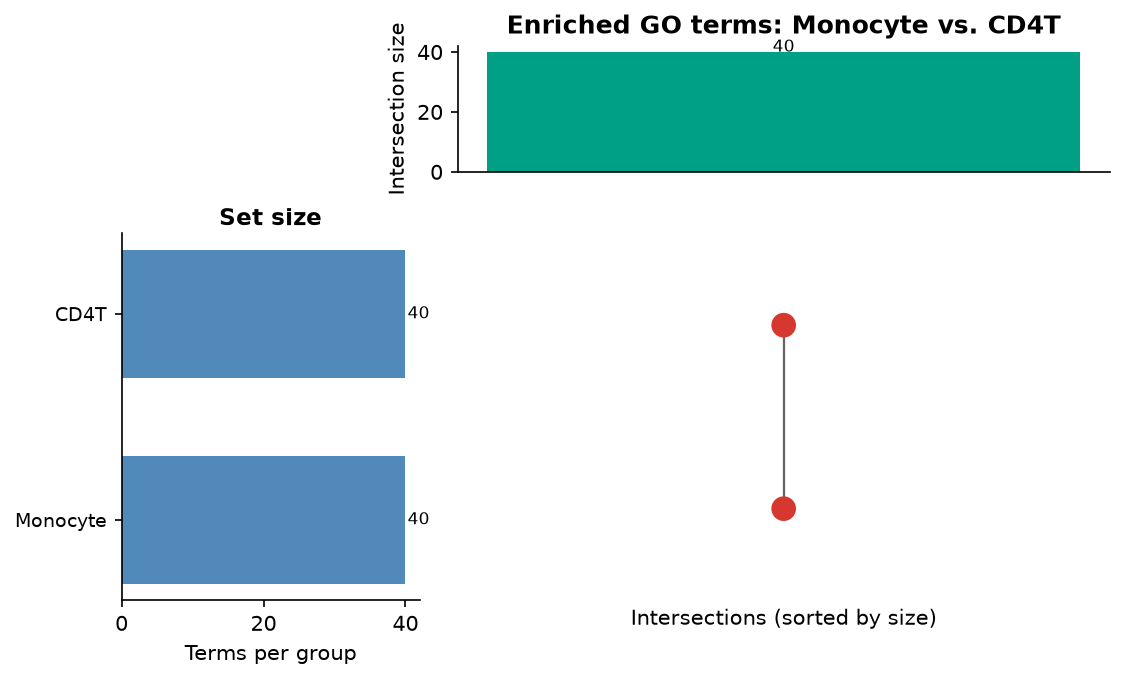

In [37]:
scat.pl.enrich_upsetplot(cmp_res, pval_cutoff=0.05, title="Enriched GO terms: Monocyte vs. CD4T");

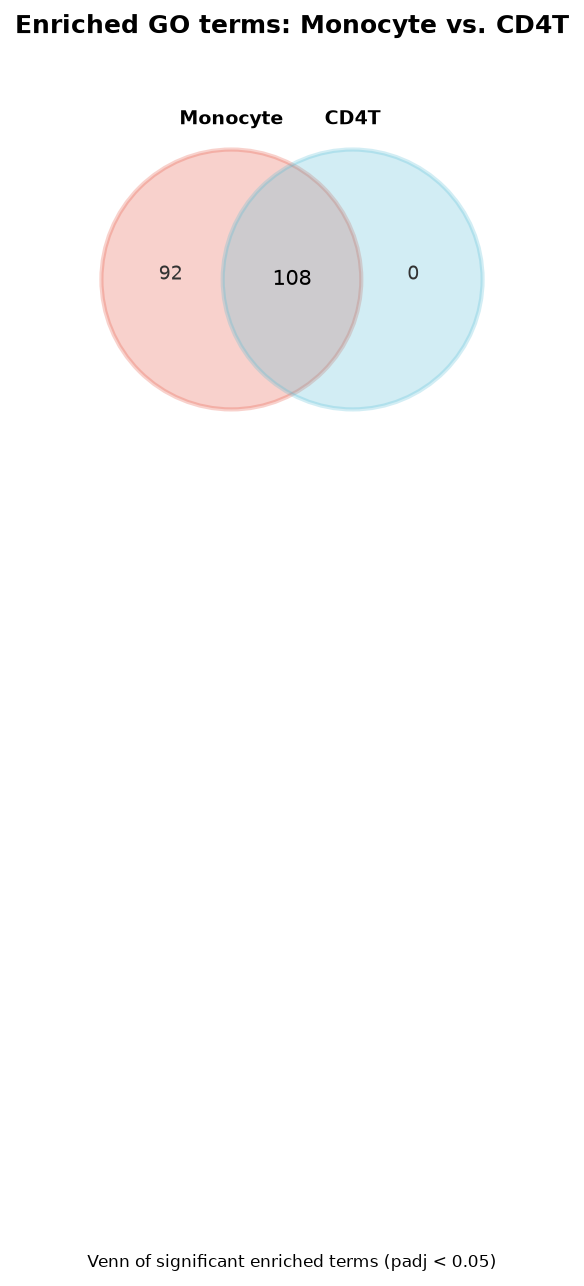

In [38]:
scat.pl.enrich_vennplot(cmp_res, pval_cutoff=0.05, title="Enriched GO terms: Monocyte vs. CD4T");

### Heatmap of top candidate genes

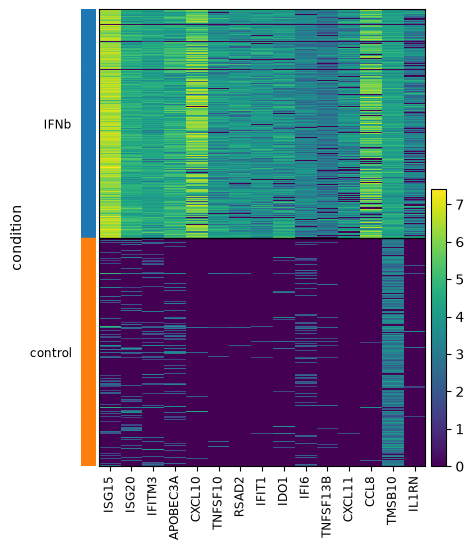

In [39]:
scat.pl.active_genes_heatmap(adata_norm, candidate_genes[:15], groupby="condition");

### Not applicable here

`comet_plot`, `bias_diagnostic_plot`, `velocity_phase_portraits`, and
`gamma_shrinkage_plot` need nascent residual / gamma columns from the
velocity-aware path — see {doc}`t_gse226488_partition_mechanism` or the
{doc}`synthetic gallery <t_synthetic_visualization>`.

## Recap

Without touching a spliced/unspliced layer, this notebook covered:

- Three DE backends (`de_method="wilcoxon"`, `use_pseudobulk=True` +
  PyDESeq2, `use_memento_de=True`) on a well-powered, real 8-donor IFN-β vs.
  control comparison — thousands of genes reach genome-wide significance,
  and the three backends agree on the strongest hits.
- The full enrichment toolkit: `run_enrichment`, `run_kegg`,
  `run_go(ontology="ALL")`, `run_gsea`, `simplify_enrichment` (both
  methods, with a concrete before/after example and a paired dotplot),
  `compare_enrichment` / `concat_compare_results` across two real cell
  types, and the export helpers.
- Plotting: volcano (3 styles), enrichment dot/bar plots (including the
  GSEA NES dotplot and running-score plot), the compareCluster-style grid
  on both a cell-type axis and a database axis, UpSet/Venn comparison
  plots, and a marker-gene heatmap.

See also: {doc}`../user_guide/standalone_de`, {doc}`../user_guide/enrichment`,
{doc}`../user_guide/plotting`, {doc}`../statistical_guidance`,
{doc}`../references`, and {doc}`t_gse226488_partition_mechanism` if your data
has spliced/unspliced layers.